### Plotting the Normalized Frequency for each fragment length in `query.bed`

In [8]:
import matplotlib.pyplot as plt
from collections import defaultdict
import random

fragment_length_counts = defaultdict(int)
total_fragments = 0

# Read `query.bed` and calculate fragment lengths
with open("query.bed", "r") as query_file:
    for line in query_file:
        fields = line.strip().split()
        if len(fields) < 3:
            continue
        try:
            start = int(fields[1])
            end = int(fields[2])
            length = end - start
            if length > 0:
                fragment_length_counts[length] += 1
                total_fragments += 1
        except ValueError:
            continue

lengths = sorted(fragment_length_counts)
normalized_frequencies = [fragment_length_counts[length] / total_fragments for length in lengths]

print(f"Total fragments: {total_fragments}")

for length, frequency in zip(lengths, normalized_frequencies):
    print(f"Length: {length}, Frequency: {frequency:.4f}")

Total fragments: 13835737
Length: 24, Frequency: 0.0000
Length: 25, Frequency: 0.0001
Length: 26, Frequency: 0.0002
Length: 27, Frequency: 0.0002
Length: 28, Frequency: 0.0002
Length: 29, Frequency: 0.0003
Length: 30, Frequency: 0.0004
Length: 31, Frequency: 0.0004
Length: 32, Frequency: 0.0005
Length: 33, Frequency: 0.0005
Length: 34, Frequency: 0.0007
Length: 35, Frequency: 0.0104
Length: 36, Frequency: 0.0103
Length: 37, Frequency: 0.0102
Length: 38, Frequency: 0.0103
Length: 39, Frequency: 0.0105
Length: 40, Frequency: 0.0111
Length: 41, Frequency: 0.0115
Length: 42, Frequency: 0.0114
Length: 43, Frequency: 0.0108
Length: 44, Frequency: 0.0101
Length: 45, Frequency: 0.0099
Length: 46, Frequency: 0.0102
Length: 47, Frequency: 0.0103
Length: 48, Frequency: 0.0107
Length: 49, Frequency: 0.0110
Length: 50, Frequency: 0.0114
Length: 51, Frequency: 0.0116
Length: 52, Frequency: 0.0116
Length: 53, Frequency: 0.0114
Length: 54, Frequency: 0.0106
Length: 55, Frequency: 0.0100
Length: 56, Fr

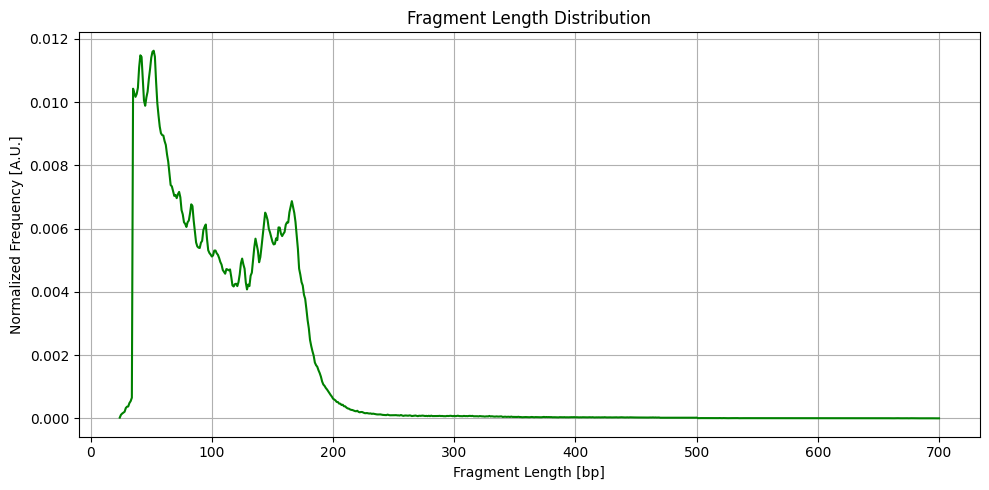

In [9]:
plt.figure(figsize=(10, 5))

plt.title("Fragment Length Distribution")

plt.plot(lengths, normalized_frequencies, color='green')

plt.xlabel("Fragment Length [bp]")
plt.ylabel("Normalized Frequency [A.U.]")

plt.grid(True)
plt.tight_layout()
plt.show()

### Rescaling of query fragments along the reference distribution

This section performs the following steps:
1. Load the reference fragment length distribution
2. Group query fragments by length
3. Resample fragments to match the reference distribution
4. Visualize the original and rescaled distributions

In [10]:
reference_distribution = {}

# Load reference distribution from `reference.hist`
with open("reference.hist") as reference_file:
    for line in reference_file:
        parts = line.strip().split()
        if len(parts) < 2:
            continue
        ref_length = int(parts[0])
        ref_frequency = float(parts[1])
        reference_distribution[ref_length] = ref_frequency

total_reference_frequency = sum(reference_distribution.values())
normalized_reference = {length: freq / total_reference_frequency for length, freq in reference_distribution.items()}

In [11]:
fragments_by_length = defaultdict(list)

# Group fragments by length from `query.bed`
with open("query.bed", "r") as query_file:
    for line in query_file:
        fields = line.strip().split()
        if len(fields) < 3:
            continue
        try:
            start = int(fields[1])
            end = int(fields[2])
            length = end - start
            if length > 0:
                fragments_by_length[length].append(line.strip())
        except ValueError:
            continue

total_available_fragments = sum(len(fragments) for fragments in fragments_by_length.values())

In [12]:
resampled_fragments = []

# Resample fragments to match reference distribution
for target_length, target_fraction in normalized_reference.items():
    if target_length in fragments_by_length:
        available_fragments = fragments_by_length[target_length]
        desired_count = int(round(target_fraction * total_available_fragments))
        selected_fragments = random.sample(available_fragments, min(desired_count, len(available_fragments)))
        resampled_fragments.extend(selected_fragments)

In [13]:
resampled_length_counts = defaultdict(int)
for fragment in resampled_fragments:
    fields = fragment.strip().split()
    length = int(fields[2]) - int(fields[1])
    resampled_length_counts[length] += 1

total_resampled_fragments = sum(resampled_length_counts.values())
resampled_lengths = sorted(resampled_length_counts.keys())
resampled_frequencies = [resampled_length_counts[length] / total_resampled_fragments for length in resampled_lengths]

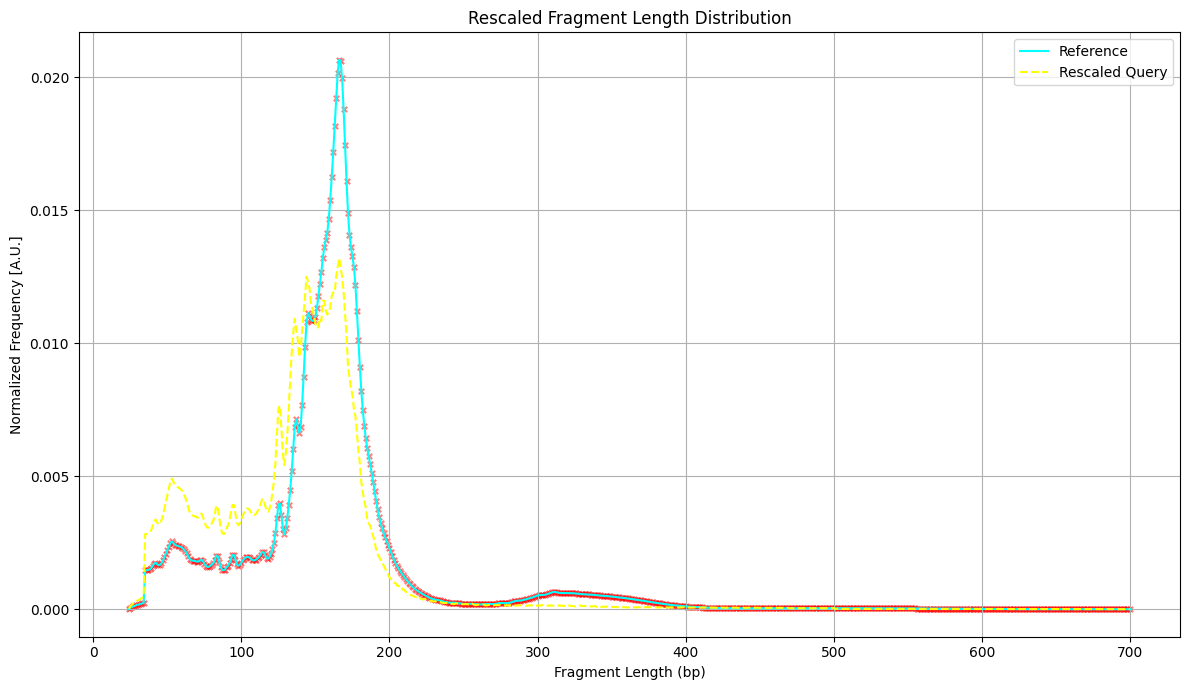

In [14]:
plt.figure(figsize=(12, 7))

reference_lengths = sorted(normalized_reference.keys())
reference_frequencies = [normalized_reference[length] for length in reference_lengths]

plt.title("Rescaled Fragment Length Distribution")

plt.plot(reference_lengths, reference_frequencies, label="Reference", color='cyan')
plt.scatter(reference_lengths, reference_frequencies, color='red', marker='x', s=15, alpha=0.5)

plt.plot(resampled_lengths, resampled_frequencies, label="Rescaled Query", color='yellow', linestyle='dashed')

plt.legend()

plt.xlabel("Fragment Length (bp)")
plt.ylabel("Normalized Frequency [A.U.]")

plt.grid(True)
plt.tight_layout()
plt.show()